# Statistical Inference Illustration
This notebook generates Gaussian-like data, visualizes its histogram, and infers the population mean and variance from the sample.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, amssymb}')
plt.rc('axes', titlesize=24, labelsize=20)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')
plt.rc('figure', figsize=(10, 4), dpi=110)

In [2]:
# Simulate Gaussian-like observations
rng = np.random.default_rng(7)
true_mu = 2.0
true_sigma = 1.3
n = 500
samples = rng.normal(loc=true_mu, scale=true_sigma, size=n)

# Infer mean and variance from the sample
mu_hat = np.mean(samples)
sigma2_hat = np.var(samples, ddof=1)
sigma_hat = np.sqrt(sigma2_hat)

# Standard error and 95% confidence interval for the mean
se_mu = sigma_hat / np.sqrt(n)
ci_low = mu_hat - 1.96 * se_mu
ci_high = mu_hat + 1.96 * se_mu

print(f'Estimated mean (mu_hat): {mu_hat:.4f}')
print(f'Estimated variance (sigma_hat^2): {sigma2_hat:.4f}')
print(f'95% CI for mean: [{ci_low:.4f}, {ci_high:.4f}]')

Estimated mean (mu_hat): 1.8332
Estimated variance (sigma_hat^2): 1.4866
95% CI for mean: [1.7263, 1.9400]


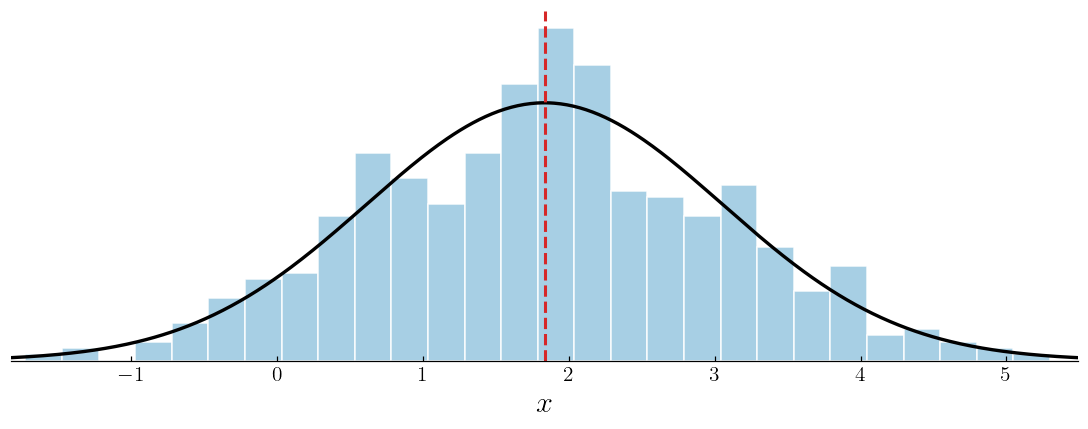

In [3]:
fig, ax = plt.subplots()

# Histogram (empirical distribution)
ax.hist(samples, bins=30, density=True, color='#9ecae1', edgecolor='white', alpha=0.9)

# Fitted Gaussian density using inferred parameters
x_min, x_max = mu_hat - 3 * sigma_hat, mu_hat + 3 * sigma_hat
x_plot = np.linspace(x_min, x_max, 500)
pdf_hat = (1.0 / (np.sqrt(2.0 * np.pi) * sigma_hat)) * np.exp(-0.5 * ((x_plot - mu_hat) / sigma_hat) ** 2)
ax.plot(x_plot, pdf_hat, color='black', linewidth=2.2)

# Visual cue for inferred mean
ax.axvline(mu_hat, color='#d62728', linestyle='--', linewidth=2.0)

# ax.set_title(r'Infer $\mu$ and $\sigma^2$ from Data')
ax.set_xlabel(r'$x$')
ax.set_xlim(x_min, x_max)

# Remove y-axis completely
ax.yaxis.set_visible(False)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

os.makedirs('figures', exist_ok=True)
plt.tight_layout()
plt.savefig('figures/statistical_inference_illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()